# Simple rule demo

Visualize the price paths implied by the strategy rules in `1d_state.py` and compare the immediate vs delayed (two-step) reset behaviour for `rule_undercut_with_reset`.

In [ ]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (6, 4)


In [ ]:
# ==========================================
# --- 1. SYSTEM CONFIGURATION ---
# ==========================================
num_sellers = 4  # <--- CHANGE THIS (2, 3, 4, 5, etc.)
num_grids = 10
T = 50
gamma = 0.95
# N_big_periods = 1000000
N_big_periods = 1000000
alpha = 0.15

# CHANGE 1: Updated Beta as requested
beta = 10 / N_big_periods

# Parameters (Symmetric)
a_val = 2
c_val = 1
# mu = 0.25
mu = 0.02
a0 = 0

xi = 0.1 # for price grid, follow Calvano et al. 2025


def get_demand_and_profit(prices):
    """
    Input: list or array of prices [p1, p2, ..., pN]
    Output: list of profits [pi1, pi2, ..., piN]
    Numerical stable version using Max-Subtraction Trick
    """
    prices = np.array(prices)
    
    logits = (a_val - prices) / mu
    logit0 = a0 / mu
    
    max_logit = np.max(logits)
    max_logit = max(max_logit, logit0)
    
    exps = np.exp(logits - max_logit)
    exp0 = np.exp(logit0 - max_logit)
    
    denom = np.sum(exps) + exp0
    demands = exps / denom
    
    profits = (prices - c_val) * demands
    return profits

# --- Grid Construction Helpers ---
def neg_joint_profit_Np(p_scalar_list):
    '''negative joint profit for N players with same price'''
    p = p_scalar_list[0]
    prices = [p] * num_sellers
    prof = get_demand_and_profit(prices)
    return -np.sum(prof)


def neg_own_profit_Np(p_own_list, p_comp):
    '''negative own profit for N players with same p_comp as competitors' price'''
    p_own = p_own_list[0]
    prices = [p_own] + [p_comp] * (num_sellers - 1)
    prof = get_demand_and_profit(prices)
    return -prof[0]


# 1. Find Monopoly Price: all sellers set same price to maximize joint profit
res_monopoly = minimize(neg_joint_profit_Np, x0=[1.5], bounds=[(1.0, 5.0)])
p_monopoly = res_monopoly.x[0]

# 2. Find Nash Price: p_nash is best response given n-1 competitors also set p_nash
p_nash = 1.1
for _ in range(10):
    res_br = minimize(neg_own_profit_Np, x0=[p_nash], args=(p_nash,), bounds=[(1.0, 5.0)])
    p_nash = res_br.x[0]

# 3. Create Grid
grid_low = p_nash - xi * (p_monopoly - p_nash)
grid_high = p_monopoly + xi * (p_monopoly - p_nash)
price_grid = np.linspace(grid_low, grid_high, num_grids)

print(f"Simulation Setup: {num_sellers} Sellers")
print(f"Price Grid: {price_grid[0]:.4f}, {price_grid[1]:.4f} ...{price_grid[-2]:.4f}, {price_grid[-1]:.4f}")
print(f"Nash Price: {p_nash:.4f}, Monopoly Price: {p_monopoly:.4f}")


# ==========================================
# --- 3. FLEXIBLE RULE DEFINITIONS ---
# ==========================================

def rule_undercut(my_idx, others_min_idx, n_grids):
    """Undercut the lowest competitor by 1 grid."""
    return max(0, others_min_idx - 1)


def rule_match(my_idx, others_min_idx, n_grids):
    """Match the lowest competitor."""
    return others_min_idx


def rule_price_above(my_idx, others_min_idx, n_grids):
    """Price 1 grid above the lowest competitor."""
    return min(n_grids - 1, others_min_idx + 1)

def rule_undercut_with_reset(my_idx, others_min_idx, n_grids):
    """Undercut, but if market is at bottom (0), jump to Monopoly (Max)."""
    if others_min_idx == 0:
        return n_grids - 1
    else:
        return max(0, others_min_idx - 1)
    
def rule_match_with_reset(my_idx, others_min_idx, n_grids):
    """Match, but if market is at bottom (0), jump to Monopoly (Max)."""
    if others_min_idx == 0:
        return n_grids - 1
    else:
        return others_min_idx


# Registry. Every action is a function: def func(my_idx, others_min_idx, n_grids) -> next_price_idx
STRATEGIES = [
    rule_undercut,
    rule_match,
    rule_price_above,
    rule_undercut_with_reset,  
    # rule_match_with_reset,    # <--- Added new strategy here
]


In [13]:
def simulate_episode(start_indices, strategy_funcs, horizon=T, delayed_reset=False):
    """Return price-index history for the given start and strategies.

    If delayed_reset is True, apply a two-step reset counter for undercut_with_reset
    (mimicking MetaActionExecutor: only reset after hitting the bottom twice in a row).
    """
    current = list(start_indices)
    history = [current.copy()]
    counters = [0] * len(strategy_funcs)
    for _ in range(horizon):
        next_indices = []
        for i, func in enumerate(strategy_funcs):
            others = current[:i] + current[i + 1:]
            others_min = min(others) if others else current[i]

            if delayed_reset and func is rule_undercut_with_reset:
                # Base move: undercut with floor at 0
                candidate = max(0, others_min - 1)
                if others_min == 0:
                    counters[i] += 1
                    if counters[i] > 1:
                        candidate = num_grids - 1
                else:
                    counters[i] = 0
                next_idx = candidate
            else:
                next_idx = func(current[i], others_min, num_grids)
                if func is rule_undercut_with_reset:
                    counters[i] = 0

            next_indices.append(next_idx)
        current = next_indices
        history.append(current.copy())
    return np.asarray(history)


def plot_history(history, labels, subtitle=None):
    steps = np.arange(history.shape[0])
    fig, ax = plt.subplots()
    title = f"Price History with {num_sellers} Sellers using Repricer Rules"
    for seller in range(history.shape[1]):
        offset = 0.01 * seller
        prices = price_grid[history[:, seller]] + offset
        label = labels[seller] if seller < len(labels) else None
        ax.step(steps, prices, where="post", label=label)
    ax.set_xlabel("Period")
    ax.set_ylabel("Price")
    ax.set_title(title)
    if subtitle:
        ax.text(0.01, 0.98, subtitle, transform=ax.transAxes, va="top", ha="left", fontsize=9)
    ax.legend()
    fig.tight_layout()


start_state_default = [0] * num_sellers  # all start at the Nash index


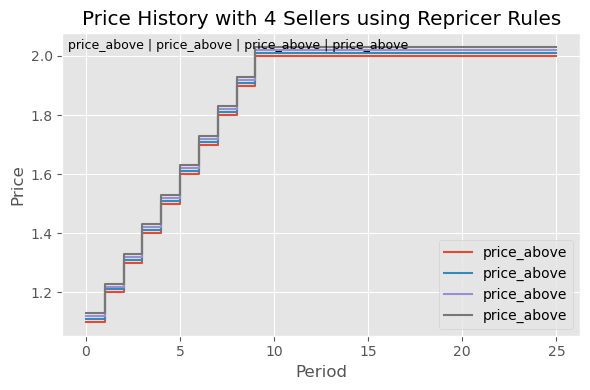

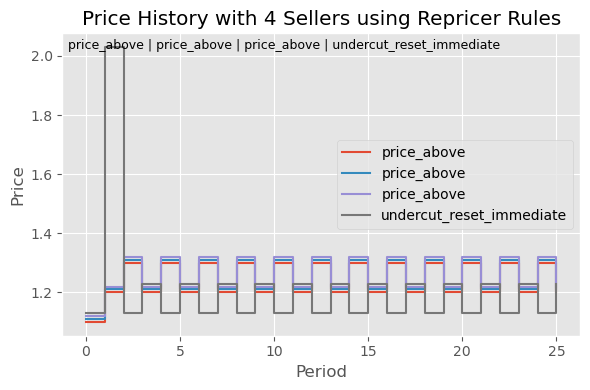

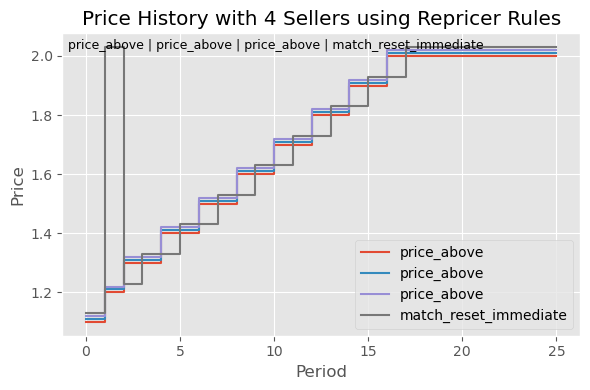

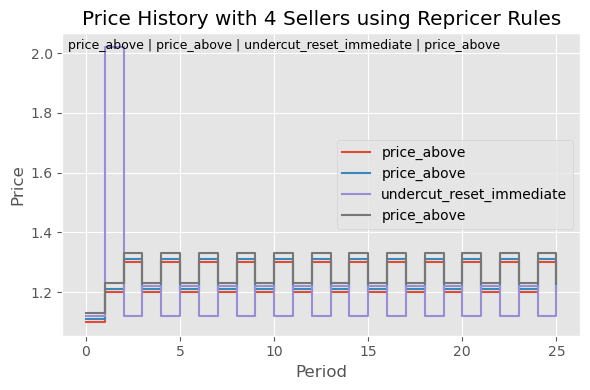

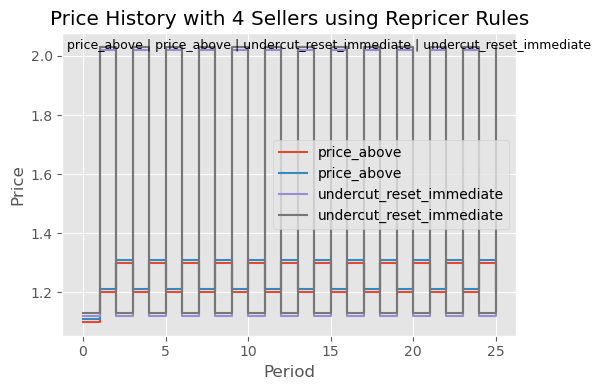

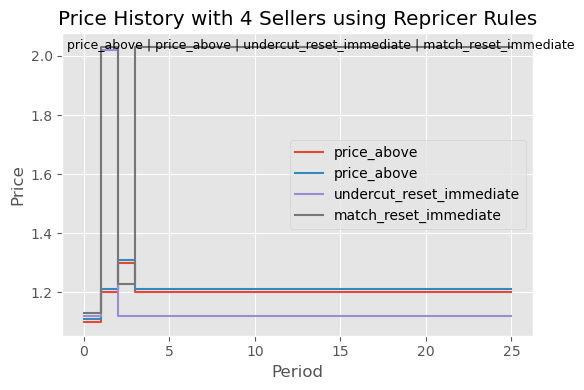

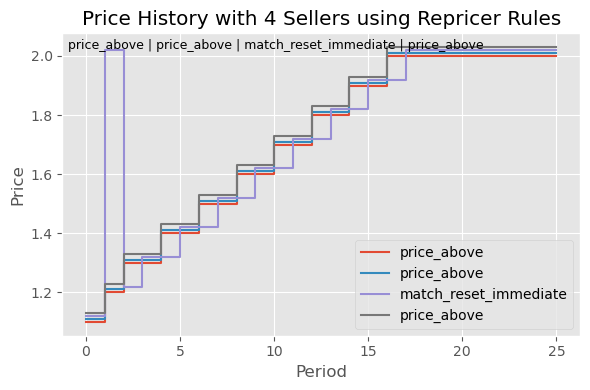

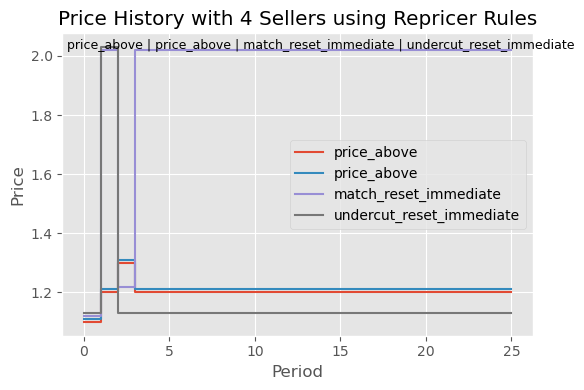

In [14]:
# Plot a sample of action profiles (default: first 8 of 3^4 = 81 profiles)
max_plots = 8  # increase to cover more combinations
action_profiles = list(itertools.product(range(len(STRATEGIES)), repeat=num_sellers))

for combo in action_profiles[:max_plots]:
    funcs = [STRATEGIES[a] for a in combo]
    labels = [STRATEGY_NAMES[a] for a in combo]
    hist = simulate_episode(start_state_default, funcs, horizon=T, delayed_reset=False)
    subtitle = " | ".join(labels)
    plot_history(hist, labels, subtitle=subtitle)


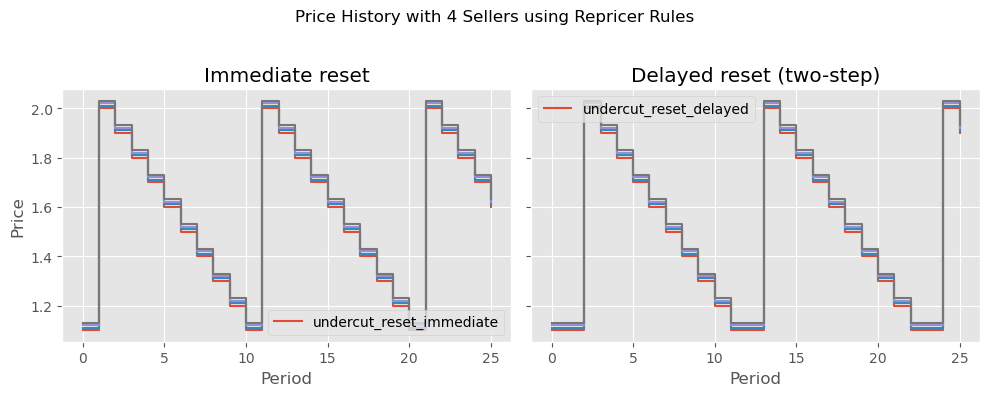

In [15]:
# Compare immediate vs delayed reset for 4 sellers all using undercut_with_reset
all_undercut = [rule_undercut_with_reset] * num_sellers
hist_immediate = simulate_episode(start_state_default, all_undercut, horizon=T, delayed_reset=False)
hist_delayed = simulate_episode(start_state_default, all_undercut, horizon=T, delayed_reset=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
fig.suptitle(f"Price History with {num_sellers} Sellers using Repricer Rules")
steps = np.arange(hist_immediate.shape[0])
label_immediate = STRATEGY_NAMES[1]
label_delayed = "undercut_reset_delayed"
for seller in range(num_sellers):
    offset = 0.01 * seller
    axes[0].step(steps, price_grid[hist_immediate[:, seller]] + offset, where="post", label=label_immediate if seller == 0 else None)
axes[0].set_title("Immediate reset")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Price")
axes[0].legend()

for seller in range(num_sellers):
    offset = 0.01 * seller
    axes[1].step(steps, price_grid[hist_delayed[:, seller]] + offset, where="post", label=label_delayed if seller == 0 else None)
axes[1].set_title("Delayed reset (two-step)")
axes[1].set_xlabel("Period")
axes[1].legend()

fig.tight_layout(rect=[0, 0, 1, 0.95])


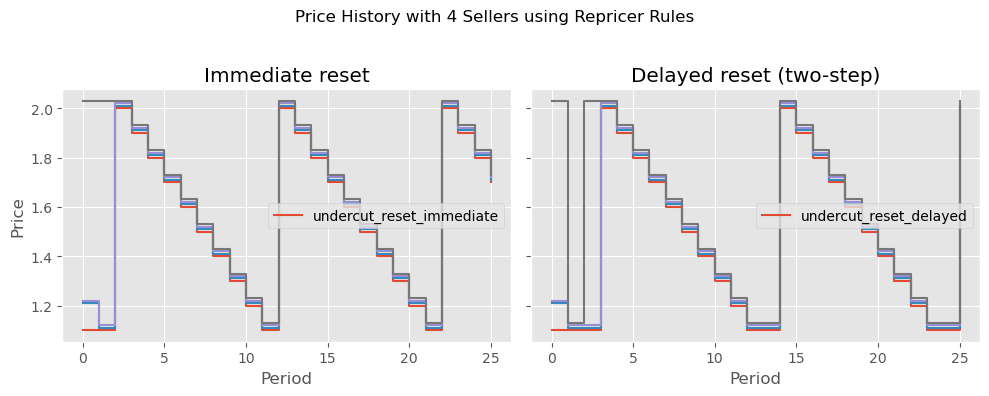

In [20]:
# Compare immediate vs delayed reset for 4 sellers all using undercut_with_reset
start_state = [0, 1, 1, -1]
all_undercut = [rule_undercut_with_reset] * num_sellers
hist_immediate = simulate_episode(start_state, all_undercut, horizon=T, delayed_reset=False)
hist_delayed = simulate_episode(start_state, all_undercut, horizon=T, delayed_reset=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
fig.suptitle(f"Price History with {num_sellers} Sellers using Repricer Rules")
steps = np.arange(hist_immediate.shape[0])
label_immediate = STRATEGY_NAMES[1]
label_delayed = "undercut_reset_delayed"
for seller in range(num_sellers):
    offset = 0.01 * seller
    axes[0].step(steps, price_grid[hist_immediate[:, seller]] + offset, where="post", label=label_immediate if seller == 0 else None)
axes[0].set_title("Immediate reset")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Price")
axes[0].legend()

for seller in range(num_sellers):
    offset = 0.01 * seller
    axes[1].step(steps, price_grid[hist_delayed[:, seller]] + offset, where="post", label=label_delayed if seller == 0 else None)
axes[1].set_title("Delayed reset (two-step)")
axes[1].set_xlabel("Period")
axes[1].legend()

fig.tight_layout(rect=[0, 0, 1, 0.95])
